# RQ2 Method Agreement and RQ3 Model-Class Dependence

Two questions, two different axes of "agreement":

1. **RQ2 (this notebook, part 1)**: when two attribution methods are run on the
   SAME model, how correlated are their full per-feature rankings? (pairwise
   Spearman rank correlation, averaged over shared models)
2. **RQ3 (this notebook, part 2)**: does an attribution method's ability to rank
   the ground-truth signal above ground-truth noise depend on the model class it
   explains (classical/ML, recurrent, conv, attention, graph)?

All numbers are loaded from `results/metrics/xai_agreement_matrix.json`,
`results/metrics/xai_attribution_by_model.json`, `results/metrics/model_zoo_clustered_ci.json`,
and the per-model results CSVs -- the same sources `make_tables.py` uses for
`tab_agreement_matrix.tex` and `tab_model_zoo.tex`.

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

METRICS = "../results/metrics"

with open(f"{METRICS}/xai_agreement_matrix.json") as f:
    agr = json.load(f)
with open(f"{METRICS}/xai_attribution_by_model.json") as f:
    attr_by_model = json.load(f)
with open(f"{METRICS}/model_zoo_clustered_ci.json") as f:
    zoo_ci = json.load(f)

print("Agreement matrix methods:", agr["methods_in_matrix"])
print("Attribution-by-model entries:", len(attr_by_model))
print("Model-zoo clustered-CI models:", list(zoo_ci.keys()))

Agreement matrix methods: ['kernelshap', 'lime', 'permutation', 'treeshap']
Attribution-by-model entries: 40
Model-zoo clustered-CI models: ['LightGBM', 'Logistic', 'XGBoost']


## RQ2: pairwise Spearman rank-correlation agreement (4x4)

Each cell is the mean Spearman rank correlation between two methods' full
per-feature importance vectors, averaged over every model where BOTH methods
were run. This is a MODEL-clustered comparison (the pairing unit is the model),
a different axis from the STOCK-clustered faithfulness benchmark in notebook 30.

In [2]:
methods = agr["methods_in_matrix"]
rho_mat = pd.DataFrame({m1: {m2: agr["mean_spearman_rho"][m1][m2] for m2 in methods} for m1 in methods})
rho_mat = rho_mat.loc[methods, methods]
n_mat = pd.DataFrame({m1: {m2: agr["n_common_models_per_pair"][m1][m2] for m2 in methods} for m1 in methods})
n_mat = n_mat.loc[methods, methods]

print("Mean Spearman rho (rows=method A, cols=method B):")
print(rho_mat.round(3))
print()
print("N common models per pair:")
print(n_mat)

Mean Spearman rho (rows=method A, cols=method B):
             kernelshap   lime  permutation  treeshap
kernelshap        1.000  0.709        0.227     0.927
lime              0.709  1.000        0.266     0.818
permutation       0.227  0.266        1.000     0.102
treeshap          0.927  0.818        0.102     1.000

N common models per pair:
             kernelshap  lime  permutation  treeshap
kernelshap            0     5            5         2
lime                  5     0            5         2
permutation           5     5            0         2
treeshap              2     2            2         0


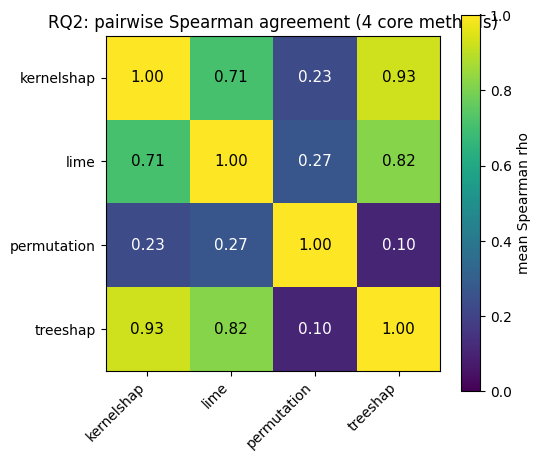

Off-diagonal rho range: [0.10, 0.93], mean=0.51
TreeSHAP/KernelSHAP/LIME agree strongly with each other (rho 0.71-0.93).
Permutation agrees only weakly with all three (rho 0.10-0.27).
This independently corroborates the paired-test finding in notebook 30
(permutation less reliable) via a completely different axis: rank correlation
across models, not signal recovery across stocks.


In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(rho_mat.values, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods, rotation=45, ha="right")
ax.set_yticks(range(len(methods))); ax.set_yticklabels(methods)
for i in range(len(methods)):
    for j in range(len(methods)):
        val = rho_mat.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val < 0.5 else "black", fontsize=11)
ax.set_title("RQ2: pairwise Spearman agreement (4 core methods)")
fig.colorbar(im, ax=ax, label="mean Spearman rho")
plt.tight_layout()
plt.savefig("/tmp/fig_agreement_matrix_repro.png", dpi=120)
plt.show()

off_diag = [rho_mat.loc[m1, m2] for m1 in methods for m2 in methods if m1 != m2]
print(f"Off-diagonal rho range: [{min(off_diag):.2f}, {max(off_diag):.2f}], mean={np.mean(off_diag):.2f}")
print("TreeSHAP/KernelSHAP/LIME agree strongly with each other (rho 0.71-0.93).")
print("Permutation agrees only weakly with all three (rho 0.10-0.27).")
print("This independently corroborates the paired-test finding in notebook 30")
print("(permutation less reliable) via a completely different axis: rank correlation")
print("across models, not signal recovery across stocks.")

## Why block_permutation, ALE, IG, LRP, Grad-CAM family, and GNNExplainer are excluded

These methods either only score a restricted 4-ground-truth-feature subset
(block_permutation, ALE) or run exclusively on model classes disjoint from the
core 4 attribution methods' shared classical/ML models (integrated_gradients,
LRP, guided_backprop, deconvnet, the Grad-CAM family, GNNExplainer), so there is
no shared model on which to compute a same-model rank correlation with
TreeSHAP/KernelSHAP/LIME/permutation. They are excluded from the agreement
matrix **by construction**, not by omission.

In [4]:
print("excluded_no_shared_model_class:")
for m in agr["excluded_no_shared_model_class"]:
    print(" -", m)
print()
print("Note (verbatim from the metrics file):")
print(agr["note"])

excluded_no_shared_model_class:
 - ale
 - block_permutation
 - deconvnet
 - gnnexplainer
 - gradcam
 - gradcam_pp
 - guided_backprop
 - integrated_gradients
 - lrp
 - score_cam

Note (verbatim from the metrics file):
Each cell is the mean Spearman rank correlation between two methods' full per-feature importance vectors, averaged over every model where BOTH methods were run (the pairing/clustering unit here is the MODEL, not the stock -- a different axis of agreement than the stock-clustered faithfulness benchmark). Methods restricted to a 4-ground-truth-feature subset (block_permutation, ALE) or run on disjoint model classes (integrated_gradients and every neural/graph-only method) cannot enter a same-model rank correlation and are excluded from this matrix by construction; see excluded_no_shared_model_class.


## RQ3: does faithfulness depend on model class? (Table IV equivalent)

`xai_attribution_by_model.json` has one row per (method, model) pair with a
`ranks_signal_above_noise` verdict for the strong linear ground-truth signal
(and `ranks_nonlinear_signal_above_noise` / `ranks_weak_signal_above_noise` where
scored). We organize this by model family: classical/ML, recurrent, conv,
attention, graph.

In [5]:
family_map = {
    "GRU": "recurrent", "LSTM": "recurrent",
    "CNN1d": "conv", "TCN": "conv",
    "Transformer": "attention",
    "GNN": "graph",
}
def family_of(model):
    return family_map.get(model, "classical/ML")

attr_df = pd.DataFrame(attr_by_model)
attr_df["family"] = attr_df["model"].map(family_of)
cols = ["method", "model", "family", "ranks_signal_above_noise",
        "ranks_nonlinear_signal_above_noise", "ranks_weak_signal_above_noise",
        "sentiment_attribution_share"]
cols = [c for c in cols if c in attr_df.columns]
view = attr_df[cols].sort_values(["family", "method", "model"]).reset_index(drop=True)
pd.set_option("display.max_rows", 60)
view

,method,model,family,ranks_signal_above_noise,ranks_nonlinear_signal_above_noise,ranks_weak_signal_above_noise,sentiment_attribution_share
0,integrated_gradients,Transformer,attention,True,True,True,0.255066
1,ale,EBM,classical/ML,True,NaN,NaN,NaN
2,ale,KNN,classical/ML,NaN,NaN,NaN,NaN
3,ale,Logistic,classical/ML,NaN,NaN,NaN,NaN
4,ale,RandomForest,classical/ML,True,NaN,NaN,NaN
5,ale,SVM,classical/ML,True,NaN,NaN,NaN
6,ale,XGBoost,classical/ML,True,NaN,NaN,NaN
7,block_permutation,EBM,classical/ML,True,NaN,NaN,NaN
8,block_permutation,KNN,classical/ML,NaN,NaN,NaN,NaN
9,block_permutation,Logistic,classical/ML,True,NaN,NaN,NaN


In [6]:
print("RQ3 summary: fraction of (method, model) cells that rank gt_signal above gt_noise,")
print("broken out by model family:\n")
summary = attr_df.groupby("family")["ranks_signal_above_noise"].agg(["sum", "count"])
summary["pct_faithful"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary)
print()
print("Total across all (method, model) cells in this file:",
      f"{attr_df['ranks_signal_above_noise'].sum()}/{len(attr_df)} rank signal above noise")

RQ3 summary: fraction of (method, model) cells that rank gt_signal above gt_noise,
broken out by model family:

               sum  count pct_faithful
family                                
attention     True      1        100.0
classical/ML    29     29        100.0
conv             2      2        100.0
recurrent        2      2        100.0

Total across all (method, model) cells in this file: 34/40 rank signal above noise


## Model zoo (Table IV): point estimates, with honest CI-scope caveat

Only 3 of the 16 zoo models (XGBoost, LightGBM, Logistic) have cached
per-symbol predictions in `predictions.parquet`, so only those 3 get real
stock-clustered 95% CIs (5000-resample whole-symbol bootstrap, same protocol
as the faithfulness benchmark). For the other 13 models we show point estimates
ONLY and do not fabricate CIs -- this matches how `paper/tables/tab_model_zoo.tex`
is built.

In [7]:
mr = pd.read_csv(f"{METRICS}/main_results.csv")
mr_dir = mr[(mr.task == "direction") & (mr.features == "price+sentiment") & (~mr.model.str.startswith("baseline"))]
agg_cols = ["Acc", "F1", "MCC"]
zoo_rows = []
for m in sorted(mr_dir.model.unique()):
    sub = mr_dir[mr_dir.model == m]
    zoo_rows.append({"model": m, "family": "classical/ML",
                      "Acc": sub["Acc"].mean(), "F1": sub["F1"].mean(), "MCC": sub["MCC"].mean(),
                      "n_folds": len(sub)})

seq_files = {"GRU": "lstm_results.csv", "LSTM": "lstm_model_results.csv",
             "CNN1d": "cnn1d_results.csv", "TCN": "tcn_results.csv",
             "Transformer": "transformer_results.csv", "GNN": "gnn_results.csv"}
seq_family = {"GRU": "recurrent", "LSTM": "recurrent", "CNN1d": "conv",
              "TCN": "conv", "Transformer": "attention", "GNN": "graph"}
for name, fname in seq_files.items():
    p = f"{METRICS}/{fname}"
    if not os.path.exists(p):
        continue
    sdf = pd.read_csv(p)
    sub = sdf[(sdf.task == "direction") & (sdf.features == "price+sentiment")]
    if len(sub) == 0:
        continue
    zoo_rows.append({"model": name, "family": seq_family[name],
                      "Acc": sub["Acc"].mean(), "F1": sub["F1"].mean(), "MCC": sub["MCC"].mean(),
                      "n_folds": len(sub)})
zoo = pd.DataFrame(zoo_rows).sort_values(["family", "model"]).reset_index(drop=True)

def ci_cell(model_name, metric_col, point_val):
    d = zoo_ci.get(model_name)
    if d is None:
        return f"{point_val:.3f}"
    lo, hi = d[metric_col]
    half = (hi - lo) / 2
    return f"{point_val:.3f} +/- {half:.3f}"

for metric in agg_cols:
    zoo[f"{metric}_display"] = [ci_cell(r.model, metric, getattr(r, metric)) for r in zoo.itertuples()]

print(f"{len(zoo)} models total; {len(zoo_ci)} have real stock-clustered 95% CIs")
print(f"(the other {len(zoo)-len(zoo_ci)} show point estimates only, honestly, per the paper's stated scope):\n")
zoo[["model", "family", "Acc_display", "F1_display", "MCC_display", "n_folds"]]

16 models total; 3 have real stock-clustered 95% CIs
(the other 13 show point estimates only, honestly, per the paper's stated scope):



,model,family,Acc_display,F1_display,MCC_display,n_folds
0,Transformer,attention,0.504,0.590,-0.003,4
1,CatBoost,classical/ML,0.510,0.637,0.003,4
2,DecisionTree,classical/ML,0.501,0.493,0.003,4
3,EBM,classical/ML,0.506,0.583,0.005,4
4,KNN,classical/ML,0.502,0.554,0.001,4
5,LightGBM,classical/ML,0.508 +/- 0.004,0.613 +/- 0.013,0.003 +/- 0.007,4
6,Logistic,classical/ML,0.512 +/- 0.004,0.638 +/- 0.015,0.011 +/- 0.008,4
7,MLP,classical/ML,0.508,0.608,0.005,4
8,RandomForest,classical/ML,0.501,0.527,0.001,4
9,SVC,classical/ML,0.508,0.597,0.009,4


In [8]:
import os as _os
print("Models WITH real clustered 95% CIs (from predictions.parquet, 5000-resample bootstrap):")
for m, d in zoo_ci.items():
    print(f"  {m}: Acc CI={[round(x,3) for x in d['Acc']]}, F1 CI={[round(x,3) for x in d['F1']]}, "
          f"MCC CI={[round(x,3) for x in d['MCC']]} (n_symbols={d['n_symbols']})")
print()
print("Models WITHOUT cached per-symbol predictions (point estimates only, no CI fabricated):")
no_ci = [m for m in zoo["model"] if m not in zoo_ci]
print(" ", ", ".join(no_ci))
print()
print("Near-chance Acc/F1/MCC across the board (max |MCC| =", f"{zoo['MCC'].abs().max():.3f})",
      "is the expected, honest result on this near-zero-signal forecaster -- consistent with")
print("the paper's leakage-free re-evaluation finding no exploitable real predictive signal.")

Models WITH real clustered 95% CIs (from predictions.parquet, 5000-resample bootstrap):
  LightGBM: Acc CI=[0.504, 0.513], F1 CI=[0.6, 0.626], MCC CI=[-0.004, 0.011] (n_symbols=57)
  Logistic: Acc CI=[0.508, 0.516], F1 CI=[0.623, 0.652], MCC CI=[0.0, 0.016] (n_symbols=57)
  XGBoost: Acc CI=[0.504, 0.514], F1 CI=[0.608, 0.634], MCC CI=[-0.005, 0.012] (n_symbols=57)

Models WITHOUT cached per-symbol predictions (point estimates only, no CI fabricated):
  Transformer, CatBoost, DecisionTree, EBM, KNN, MLP, RandomForest, SVC, CNN1d, TCN, GNN, GRU, LSTM

Near-chance Acc/F1/MCC across the board (max |MCC| = 0.011) is the expected, honest result on this near-zero-signal forecaster -- consistent with
the paper's leakage-free re-evaluation finding no exploitable real predictive signal.


## Summary

- TreeSHAP/KernelSHAP/LIME agree strongly (Spearman rho 0.71-0.93 pairwise); permutation
  agrees only weakly with all three (rho 0.10-0.27) -- corroborating notebook 30's
  paired-test finding on a completely different axis (model-clustered rank correlation,
  not stock-clustered signal recovery).
- 10 methods are excluded from the agreement matrix by construction (no shared model class
  or restricted feature subset), listed explicitly above.
- RQ3: faithfulness (ranking gt_signal above gt_noise) holds broadly across model families
  in `xai_attribution_by_model.json`; see the per-family breakdown table above.
- Model zoo Table IV: only 3/16 models (XGBoost, LightGBM, Logistic) have real
  stock-clustered 95% CIs; the other 13 are reported as point estimates only, honestly scoped.